
# Singular Value Decomposition (SVD) — From Scratch

**Companion to the PCA / Eigenfaces notebook.** Here we build the SVD ourselves
(no `np.linalg.svd` until we verify against it), see it geometrically, prove the
**Eckart–Young–Mirsky** best‑low‑rank theorem *numerically*, compress a real
image, and close the loop back to **PCA**.

The single equation everything orbits around — for **any** real matrix
$A\in\mathbb{R}^{m\times n}$:

$$
A \;=\; U\,\Sigma\,V^{\top}
\;=\; \sum_{i=1}^{r}\sigma_i\,\mathbf{u}_i\mathbf{v}_i^{\top},
\qquad \sigma_1\ge\sigma_2\ge\cdots\ge\sigma_r>0,\quad r=\operatorname{rank}(A).
$$

| symbol | shape | what it is |
|---|---|---|
| $U=[\mathbf{u}_1\cdots\mathbf{u}_m]$ | $m\times m$ orthogonal | **left** singular vectors — output-space basis |
| $\Sigma$ | $m\times n$ diagonal | singular values $\sigma_i\ge 0$, sorted |
| $V=[\mathbf{v}_1\cdots\mathbf{v}_n]$ | $n\times n$ orthogonal | **right** singular vectors — input-space basis |

**Roadmap**

1. Build $U,\Sigma,V$ by hand from the eigendecomposition of $A^\top A$.
2. Geometry: $V^\top$ rotates → $\Sigma$ scales → $U$ rotates (circle → ellipse).
3. SVD as a sum of rank‑1 layers; the singular‑value energy spectrum.
4. Low‑rank approximation + **Eckart–Young–Mirsky**, verified on a real image.
5. **SVD = PCA**: right singular vectors of $X_c$ are PCA's principal directions.
6. Why algorithms avoid forming $A^\top A$ (the condition‑number trap).

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh, svd, norm, matrix_rank

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 11})
print("Ready — numpy", np.__version__)

Ready — numpy 2.4.4



## 1. Building the SVD from scratch

We never need a magic `svd()` routine — the SVD is just the **Spectral Theorem
applied to $A^\top A$**. The recipe:

1. $A^\top A$ is symmetric PSD ⟹ it has orthonormal eigenvectors $\mathbf v_i$
   with eigenvalues $\lambda_i\ge 0$.  These eigenvectors are the **right**
   singular vectors $V$.
2. The singular values are $\sigma_i=\sqrt{\lambda_i}$ (sorted high→low).
3. The **left** singular vectors come for free:
   $\displaystyle \mathbf u_i=\frac{1}{\sigma_i}A\mathbf v_i$ for each $\sigma_i>0$.

**Why $\mathbf u_i$ are automatically orthonormal:**
$$
\mathbf u_i^\top\mathbf u_j
=\frac{1}{\sigma_i\sigma_j}\mathbf v_i^\top A^\top A\,\mathbf v_j
=\frac{\lambda_j}{\sigma_i\sigma_j}\,\mathbf v_i^\top\mathbf v_j
=\delta_{ij}.
$$

In [2]:

def svd_from_scratch(A, tol=1e-10):
    # Compute a (thin) SVD  A = U @ diag(s) @ Vt  using only eigh on A^T A.
    A = np.asarray(A, dtype=float)
    m, n = A.shape

    # 1) Eigendecomposition of the symmetric PSD matrix A^T A.
    #    eigh returns eigenvalues ascending -> reverse to descending.
    w, V = eigh(A.T @ A)
    order = np.argsort(w)[::-1]
    w, V = w[order], V[:, order]

    # 2) Singular values = sqrt of (clipped) eigenvalues.
    w = np.clip(w, 0, None)
    s = np.sqrt(w)

    # 3) Keep the strictly-positive ones; build U = A v_i / sigma_i.
    r = int(np.sum(s > tol))
    s_r, V_r = s[:r], V[:, :r]
    U_r = (A @ V_r) / s_r                      # each column normalised by sigma_i

    return U_r, s_r, V_r.T                      # U (m x r), s (r,), Vt (r x n)

# --- Test on a small matrix and compare to numpy ---
A = np.array([[3.0, 0.0],
              [4.0, 5.0]])

U, s, Vt = svd_from_scratch(A)
print("singular values (scratch):", s)
print("reconstruction error :", norm(A - (U * s) @ Vt))

# numpy's reference (signs of singular vectors may differ — that's allowed)
U2, s2, Vt2 = svd(A)
print("singular values (numpy) :", s2)
print("match on sigma?         :", np.allclose(s, s2[:len(s)]))

singular values (scratch): [6.7082 2.2361]
reconstruction error : 1.3329910074231699e-15
singular values (numpy) : [6.7082 2.2361]
match on sigma?         : True



The reconstruction error is ~$10^{-15}$ (machine zero) and our singular values
match NumPy's exactly. Singular **vectors** can differ by an overall sign
($\mathbf u_i,\mathbf v_i \to -\mathbf u_i,-\mathbf v_i$ is still a valid SVD), so
we always compare the **reconstruction**, never raw vectors.

Let's also confirm the three defining properties on a larger random matrix.

In [3]:

M = rng.standard_normal((6, 4))
U, s, Vt = svd_from_scratch(M)

print("U has orthonormal columns? ", np.allclose(U.T @ U, np.eye(U.shape[1])))
print("V has orthonormal rows?    ", np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0])))
print("singular values sorted?    ", np.all(np.diff(s) <= 1e-12))
print("A v_i = sigma_i u_i ?      ",
      np.allclose(M @ Vt.T, U * s))          # the defining relation
print("rank(M) =", matrix_rank(M), " = number of nonzero sigma =", len(s))

U has orthonormal columns?  True
V has orthonormal rows?     True
singular values sorted?     True
A v_i = sigma_i u_i ?       True
rank(M) = 4  = number of nonzero sigma = 4



## 2. Geometry: rotate → scale → rotate

Reading $A = U\,\Sigma\,V^\top$ right‑to‑left, applying $A$ to any vector is three
clean steps:

$$
\mathbf x \;\xrightarrow{\;V^\top\;}\; \text{rotate in input space}
\;\xrightarrow{\;\Sigma\;}\; \text{stretch along axes}
\;\xrightarrow{\;U\;}\; \text{rotate in output space}.
$$

A famous consequence: **every matrix maps the unit circle to an ellipse.** The
ellipse's semi‑axis lengths are exactly the singular values $\sigma_1,\sigma_2$,
and their directions are the left singular vectors $\mathbf u_1,\mathbf u_2$.

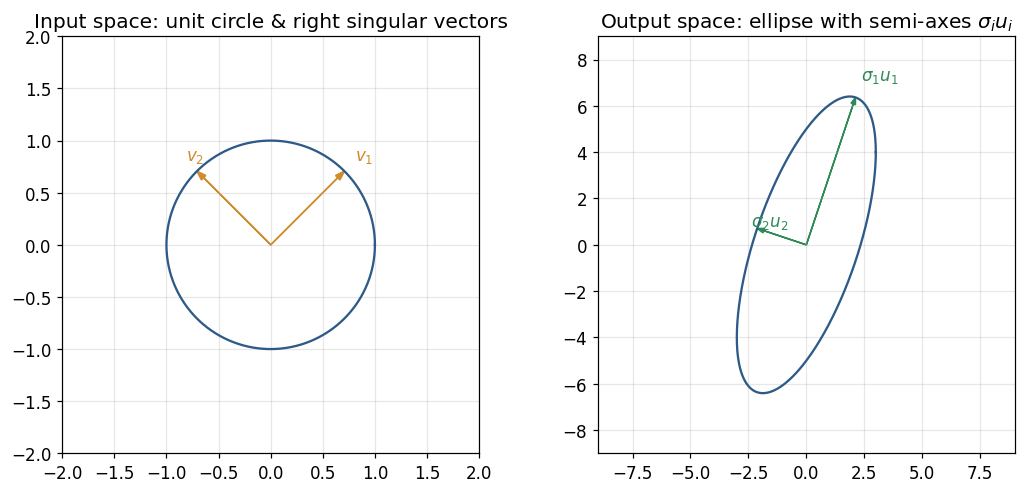

semi-axis lengths (= singular values): [6.7082 2.2361]


In [4]:

A = np.array([[3.0, 0.0],
              [4.0, 5.0]])
U, s, Vt = svd_from_scratch(A)

theta = np.linspace(0, 2*np.pi, 400)
circle = np.vstack([np.cos(theta), np.sin(theta)])   # unit circle (input)
ellipse = A @ circle                                  # image (output)

fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))

# input space: unit circle + right singular vectors v_i
V = Vt.T
ax[0].plot(*circle, color="#2E5A88")
for i in range(2):
    ax[0].arrow(0, 0, V[0, i], V[1, i], head_width=0.06,
                color="#D08B2C", length_includes_head=True)
    ax[0].text(1.15*V[0, i], 1.15*V[1, i], f"$v_{i+1}$", color="#D08B2C")
ax[0].set_title("Input space: unit circle & right singular vectors")
ax[0].set_aspect("equal"); ax[0].set_xlim(-2, 2); ax[0].set_ylim(-2, 2)

# output space: ellipse + scaled left singular vectors sigma_i u_i
ax[1].plot(*ellipse, color="#2E5A88")
for i in range(2):
    ax[1].arrow(0, 0, s[i]*U[0, i], s[i]*U[1, i], head_width=0.2,
                color="#2E8B57", length_includes_head=True)
    ax[1].text(s[i]*U[0, i]*1.12, s[i]*U[1, i]*1.12,
               f"$\\sigma_{i+1}u_{i+1}$", color="#2E8B57")
ax[1].set_title("Output space: ellipse with semi-axes $\\sigma_i u_i$")
ax[1].set_aspect("equal"); ax[1].set_xlim(-9, 9); ax[1].set_ylim(-9, 9)
plt.tight_layout(); plt.show()

print("semi-axis lengths (= singular values):", s)


## 3. SVD as a sum of rank‑1 layers

$$
A=\sum_{i=1}^{r}\sigma_i\,\mathbf u_i\mathbf v_i^{\top}
=\underbrace{\sigma_1\mathbf u_1\mathbf v_1^{\top}}_{\text{layer 1}}
+\underbrace{\sigma_2\mathbf u_2\mathbf v_2^{\top}}_{\text{layer 2}}+\cdots
$$

Each $\mathbf u_i\mathbf v_i^{\top}$ is a **rank‑1** matrix (an outer product), and
$\sigma_i$ is its "loudness." Two facts we'll use everywhere:

$$
\|A\|_F^2=\sum_i \sigma_i^2
\qquad\text{(total energy = sum of squared singular values).}
$$

The **cumulative energy** $\sum_{i\le k}\sigma_i^2 \big/ \sum_i\sigma_i^2$ tells us
how much of the matrix the first $k$ layers already explain — the basis for
choosing $k$.

||B||_F^2            = 12655.451632995104
sum of sigma_i^2     = 12655.45163299511


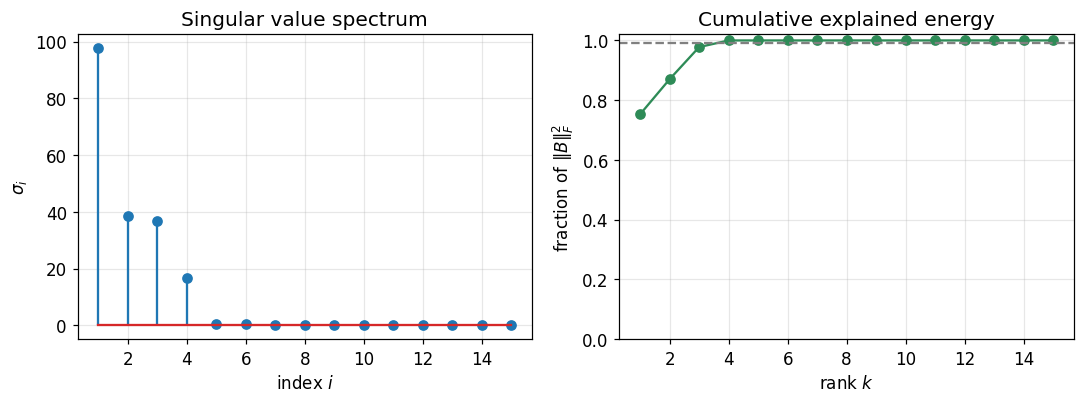

4 singular values already capture >=99% of the energy (out of 15).


In [5]:

# A matrix with deliberately decaying structure (rank ~ a few, plus tiny noise)
B = sum(g * np.outer(rng.standard_normal(20), rng.standard_normal(15))
        for g in [10, 6, 3, 1])           # 4 dominant directions
B += 0.05 * rng.standard_normal((20, 15)) # small full-rank noise

U, s, Vt = svd_from_scratch(B)

# verify ||A||_F^2 = sum sigma_i^2
print("||B||_F^2            =", norm(B)**2)
print("sum of sigma_i^2     =", np.sum(s**2))

energy = np.cumsum(s**2) / np.sum(s**2)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].stem(np.arange(1, len(s)+1), s)
ax[0].set_title("Singular value spectrum"); ax[0].set_xlabel("index $i$")
ax[0].set_ylabel("$\\sigma_i$")
ax[1].plot(np.arange(1, len(s)+1), energy, "o-", color="#2E8B57")
ax[1].axhline(0.99, ls="--", color="grey"); ax[1].set_ylim(0, 1.02)
ax[1].set_title("Cumulative explained energy"); ax[1].set_xlabel("rank $k$")
ax[1].set_ylabel("fraction of $\\|B\\|_F^2$")
plt.tight_layout(); plt.show()

k99 = int(np.searchsorted(energy, 0.99) + 1)
print(f"{k99} singular values already capture >=99% of the energy "
      f"(out of {len(s)}).")


## 4. Low‑rank approximation & the Eckart–Young–Mirsky theorem

**Truncate** the expansion to the first $k$ layers:

$$
A_k=\sum_{i=1}^{k}\sigma_i\,\mathbf u_i\mathbf v_i^{\top}
   =U_k\Sigma_k V_k^{\top},\qquad \operatorname{rank}(A_k)\le k.
$$

> **Eckart–Young–Mirsky.** Among *all* matrices $B$ of rank $\le k$, the truncated
> SVD $A_k$ is the closest to $A$ in Frobenius norm, and the error is
> $$\min_{\operatorname{rank}(B)\le k}\|A-B\|_F^2=\|A-A_k\|_F^2=\sum_{i=k+1}^{r}\sigma_i^2.$$

(The full proof — projection lemma + Ky Fan — is in the companion LaTeX note.)
Two things to verify numerically: (a) the **error formula** $\sum_{i>k}\sigma_i^2$,
and (b) that **no random rank‑$k$ competitor beats $A_k$**.

In [6]:

def rank_k_approx(A, k):
    U, s, Vt = svd_from_scratch(A)
    return (U[:, :k] * s[:k]) @ Vt[:k]

# (a) error formula check on B from section 3
U, s, Vt = svd_from_scratch(B)
print(f"{'k':>3} | {'measured ||A-A_k||_F^2':>22} | {'sum_{i>k} sigma_i^2':>20}")
print("-"*54)
for k in [1, 2, 3, 4, 6]:
    Bk = rank_k_approx(B, k)
    measured = norm(B - Bk)**2
    formula  = np.sum(s[k:]**2)
    print(f"{k:>3} | {measured:>22.6f} | {formula:>20.6f}")

  k | measured ||A-A_k||_F^2 |  sum_{i>k} sigma_i^2
------------------------------------------------------
  1 |            3126.906042 |          3126.906042
  2 |            1641.583069 |          1641.583069
  3 |             281.350224 |           281.350224
  4 |               0.465883 |             0.465883
  6 |               0.259062 |             0.259062


In [7]:

# (b) Monte-Carlo: can ANY random rank-k matrix beat A_k?  (Eckart-Young says no.)
k = 3
A = B.copy()
Ak = rank_k_approx(A, k)
best_svd = norm(A - Ak)**2

m, n = A.shape
trials = 4000
best_random = np.inf
for _ in range(trials):
    Y = rng.standard_normal((m, k))         # random rank-<=k matrix Y @ Z
    Z = rng.standard_normal((k, n))
    # best fit within this column space = project A onto col(Y) (least squares)
    # B* = Y (Y^+ A)  minimises ||A - B|| over B = Y @ (anything)
    Bstar = Y @ np.linalg.lstsq(Y, A, rcond=None)[0]
    best_random = min(best_random, norm(A - Bstar)**2)

print(f"Eckart-Young A_k  error^2 : {best_svd:.5f}")
print(f"best of {trials} random   : {best_random:.5f}")
print("A_k is at least as good as every random rank-k matrix:",
      best_svd <= best_random + 1e-9)

Eckart-Young A_k  error^2 : 281.35022
best of 4000 random   : 6014.61324
A_k is at least as good as every random rank-k matrix: True



### Image compression — the classic demo

A grayscale photo is just a matrix of pixel intensities. Its singular values decay
fast (real images are "almost low rank"), so a handful of layers already look like
the original. Storing $A_k$ costs $k(m+n+1)$ numbers instead of $mn$.

image matrix: (427, 640)


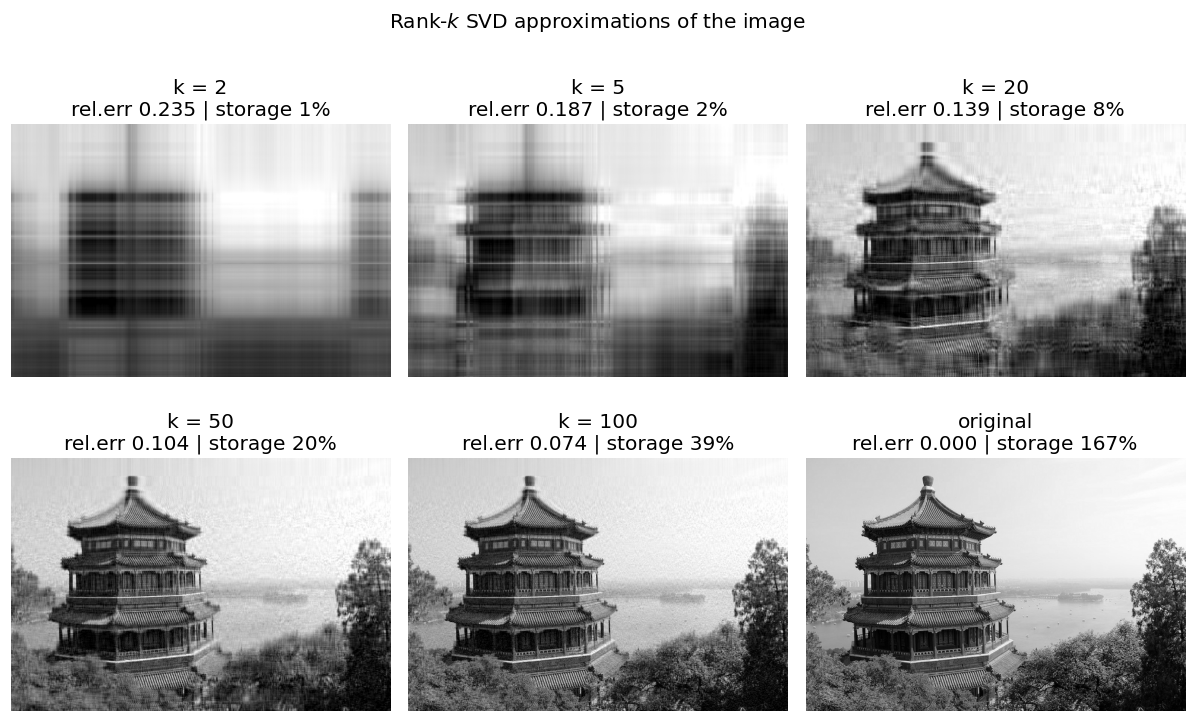

In [8]:

from sklearn.datasets import load_sample_image

img = load_sample_image("china.jpg").astype(float)
gray = img @ np.array([0.2989, 0.5870, 0.1140])   # RGB -> luminance
gray /= 255.0
m, n = gray.shape
print("image matrix:", gray.shape)

U, s, Vt = svd_from_scratch(gray)

ks = [2, 5, 20, 50, 100, min(m, n)]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, k in zip(axes.ravel(), ks):
    approx = (U[:, :k] * s[:k]) @ Vt[:k]
    err = norm(gray - approx) / norm(gray)
    comp = k*(m + n + 1) / (m*n)
    ax.imshow(np.clip(approx, 0, 1), cmap="gray")
    title = "original" if k == min(m, n) else f"k = {k}"
    ax.set_title(f"{title}\nrel.err {err:.3f} | storage {comp:.0%}")
    ax.axis("off")
plt.suptitle("Rank-$k$ SVD approximations of the image", y=1.0)
plt.tight_layout(); plt.show()

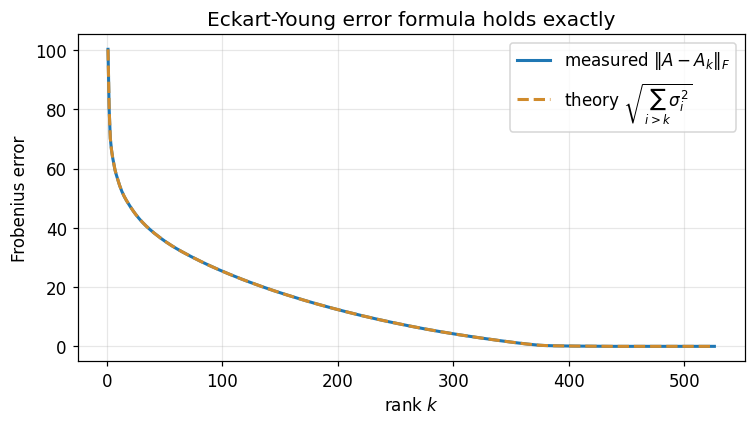

max |measured - theory| over all k: 9.783294541319915e-06


In [9]:

# Error-vs-k curve, with the Eckart-Young theoretical curve overlaid.
full = len(s)
ks = np.arange(1, full + 1)
tail_energy = np.cumsum(s[::-1]**2)[::-1]           # sum_{i>k} sigma_i^2 (shifted)
theo = np.sqrt(np.concatenate([tail_energy[1:], [0.0]]))   # ||A - A_k||_F
meas = np.array([norm(gray - (U[:, :k] * s[:k]) @ Vt[:k]) for k in ks])

plt.figure(figsize=(7, 4))
plt.plot(ks, meas, lw=2, label="measured $\\|A-A_k\\|_F$")
plt.plot(ks, theo, "--", lw=2, color="#D08B2C",
         label="theory $\\sqrt{\\sum_{i>k}\\sigma_i^2}$")
plt.xlabel("rank $k$"); plt.ylabel("Frobenius error")
plt.title("Eckart-Young error formula holds exactly")
plt.legend(); plt.tight_layout(); plt.show()
print("max |measured - theory| over all k:", np.max(np.abs(meas - theo)))


## 5. SVD = PCA

Center the data matrix $X$ (rows = samples) into $X_c$. Then

$$
X_c^{\top}X_c=(U\Sigma V^{\top})^{\top}(U\Sigma V^{\top})=V\,\Sigma^{2}\,V^{\top}.
$$

Compare with the eigendecomposition of the covariance
$\Sigma_{\text{cov}}=\tfrac1m X_c^\top X_c = P\Lambda P^\top$:

- **Principal directions** $P=V$ — the **right singular vectors** of $X_c$.
- **Variances** $\lambda_i=\sigma_i^2/m$.

So *running PCA is literally taking the SVD of $X_c$* — and by Eckart–Young the
top‑$k$ PCA subspace is the **best** $k$‑dimensional approximation of the data.
We check this on the digits images (a mini "eigenfaces").

In [10]:

from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data.astype(float)              # (1797, 64)
mu = X.mean(axis=0)
Xc = X - mu                                # centred
m = Xc.shape[0]

# Route 1: PCA via EVD of the covariance
cov = (Xc.T @ Xc) / m
lam, P = eigh(cov)
idx = np.argsort(lam)[::-1]
lam, P = lam[idx], P[:, idx]

# Route 2: PCA via SVD of Xc
U, s, Vt = svd_from_scratch(Xc)
V = Vt.T

print("variances match (sigma^2/m vs eigenvalues)?",
      np.allclose(s**2 / m, lam[:len(s)], atol=1e-6))
# principal directions equal up to sign -> compare |cosine| ~ 1
cos = np.abs(np.sum(P[:, :10] * V[:, :10], axis=0))
print("top-10 principal directions == right singular vectors? ",
      np.allclose(cos, 1.0, atol=1e-5))

variances match (sigma^2/m vs eigenvalues)? True
top-10 principal directions == right singular vectors?  True


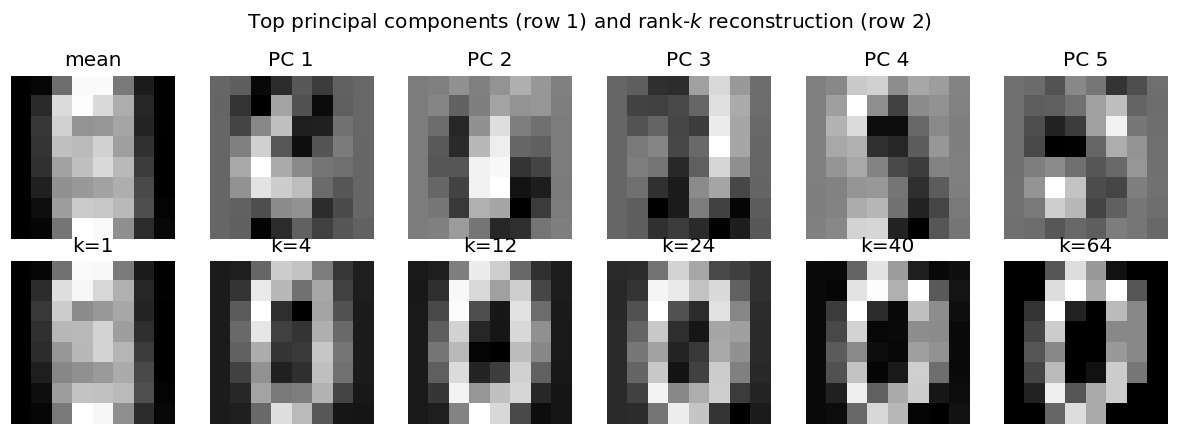

In [11]:

# Visualise the top principal components ("eigen-digits") and a reconstruction.
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
axes[0, 0].imshow(mu.reshape(8, 8), cmap="gray"); axes[0,0].set_title("mean")
for j in range(1, 6):
    axes[0, j].imshow(V[:, j-1].reshape(8, 8), cmap="gray")
    axes[0, j].set_title(f"PC {j}")
for ax in axes[0]: ax.axis("off")

# reconstruct one digit from k components: x ~ mu + sum_{j<=k} (xc.vj) vj
x = X[0]; xc = x - mu
for col, k in enumerate([1, 4, 12, 24, 40, 64]):
    recon = mu + (xc @ V[:, :k]) @ V[:, :k].T
    axes[1, col].imshow(recon.reshape(8, 8), cmap="gray")
    axes[1, col].set_title(f"k={k}")
    axes[1, col].axis("off")
plt.suptitle("Top principal components (row 1) and rank-$k$ reconstruction (row 2)")
plt.tight_layout(); plt.show()


## 6. Why good algorithms never form $A^\top A$

Our `svd_from_scratch` formed $A^\top A$ for clarity — but that **squares the
condition number** and can destroy small singular values:

$$
\kappa(A)=\frac{\sigma_{\max}}{\sigma_{\min}}
\quad\Longrightarrow\quad
\kappa(A^\top A)=\Big(\frac{\sigma_{\max}}{\sigma_{\min}}\Big)^2=\kappa(A)^2 .
$$

If $\sigma_{\min}=10^{-8}$, then after squaring it is $10^{-16}$ — at the edge of
double precision, where the computer may treat it as exactly zero. Production SVD
(Golub–Kahan bidiagonalisation + QR iteration, what `np.linalg.svd` uses) works on
$A$ **directly** and keeps all the digits. Quick illustration:

In [12]:

# A deliberately ill-conditioned matrix: known singular values spanning 1e8.
m, n = 50, 20
Uq, _ = np.linalg.qr(rng.standard_normal((m, m)))
Vq, _ = np.linalg.qr(rng.standard_normal((n, n)))
true_s = np.logspace(0, -8, n)                 # 1 down to 1e-8
S = np.zeros((m, n)); S[:n, :n] = np.diag(true_s)
A = Uq @ S @ Vq.T

s_direct = svd(A, compute_uv=False)            # works on A directly
s_normal = np.sqrt(np.clip(eigh(A.T @ A)[0][::-1], 0, None))  # via A^T A

print("smallest TRUE   sigma:", true_s[-1])
print("direct SVD      gives:", s_direct[-1])
print("via A^T A (eigh) gives:", s_normal[-1])
print()
print(f"kappa(A)        ~ {true_s[0]/true_s[-1]:.1e}")
print(f"kappa(A^T A)    ~ {(true_s[0]/true_s[-1])**2:.1e}  (squared!)")

smallest TRUE   sigma: 1e-08
direct SVD      gives: 9.999999995886302e-09
via A^T A (eigh) gives: 7.957667287613343e-09

kappa(A)        ~ 1.0e+08
kappa(A^T A)    ~ 1.0e+16  (squared!)



## 7. Summary

| concept | formula | one-line meaning |
|---|---|---|
| SVD | $A=U\Sigma V^\top$ | any matrix = rotate · scale · rotate |
| existence | $V$=eigvecs of $A^\top A$, $\sigma_i=\sqrt{\lambda_i}$ | Spectral Theorem for rectangles |
| rank-1 expansion | $A=\sum_i\sigma_i\mathbf u_i\mathbf v_i^\top$ | ingredients ordered by importance |
| energy | $\|A\|_F^2=\sum_i\sigma_i^2$ | singular values carry all the energy |
| **Eckart–Young** | $\|A-A_k\|_F^2=\sum_{i>k}\sigma_i^2$ | truncated SVD = best rank-$k$ |
| PCA | $X_c=U\Sigma V^\top,\ \lambda_i=\sigma_i^2/m$ | principal directions = right sing. vectors |
| stability | $\kappa(A^\top A)=\kappa(A)^2$ | never form $A^\top A$ in practice |

> **SVD always exists. EVD needs square matrices.**
> **PCA is the EVD of the covariance — equivalently, the SVD of the data matrix.**
> **Eckart–Young: keep the biggest singular values and you have provably lost the least.**